In [6]:
import umap
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcol
from scipy.optimize import curve_fit
from sklearn.preprocessing import StandardScaler
from matplotlib import ticker
#from matplotlib.gridspec import GridSpec
import scipy.stats as sts
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy.ma as nma

plt.style.use('./presentation.mplstyle')


In [3]:
sources = pd.read_csv('v1saga_dwarfs.csv')
print(sources.shape)

smorph = pd.read_csv('saga_morph.csv')
print(smorph.shape)

(6337, 26)
(6211, 78)


In [4]:
bands = {'g':[mcm.Blues,'tab:blue'],'r':[mcm.Greens,'tab:green'],'i':[mcm.Oranges,'tab:orange'],'z':[mcm.Reds,'tab:red']}


In [7]:
selc = smorph[(smorph['snr_pix_g']>2)&(smorph['flag_g']<=1)&(smorph['snr_pix_r']>2)&(smorph['flag_r']<=1)]
print(selc.shape)

penguin_data = selc[
    ['gini_g', 'm20_g', 'c_g', 'a_g', 's_g', 'a_s_g','rpetro_g', 'n_g', 'rhalf_g',
    'gini_r', 'm20_r', 'c_r', 'a_r', 's_r', 'a_s_r','rpetro_r', 'n_r', 'rhalf_r']].values
scaled_data = StandardScaler().fit_transform(penguin_data)

(5807, 78)


In [21]:
reducer = umap.UMAP(min_dist=0.08,n_neighbors=8)
embedding = reducer.fit_transform(scaled_data)
print(embedding.shape)

(5807, 2)


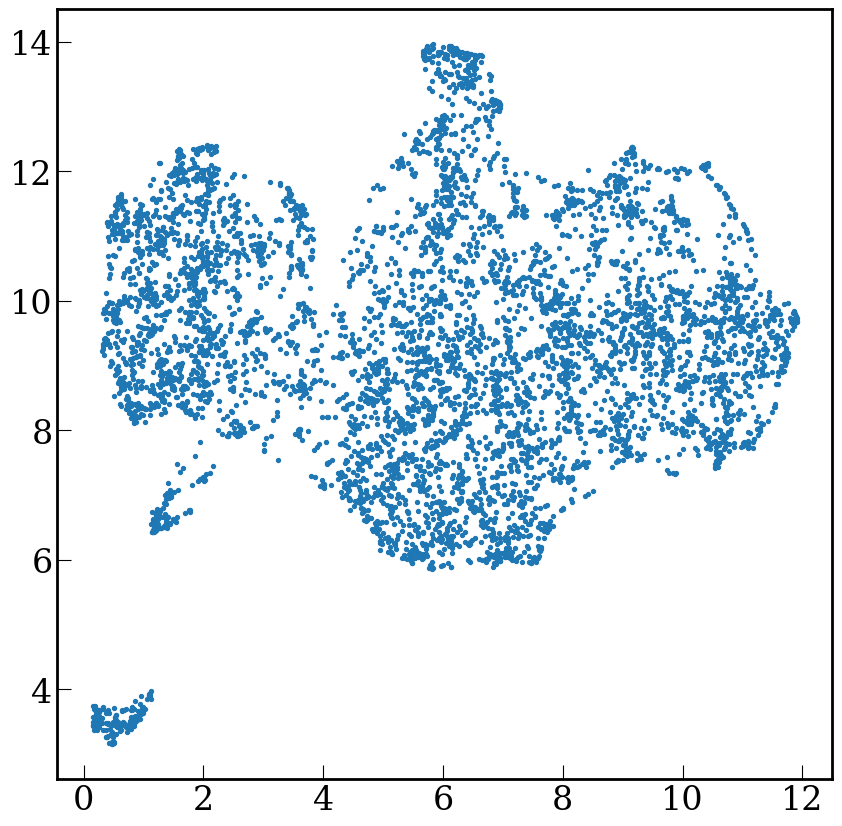

In [20]:
fig,ax=plt.subplots(figsize=(10,10))

ax.scatter(embedding[:,0],embedding[:,1],s=8)
